In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

In [ ]:

sample_fraction = 0.2

In [ ]:

file_path = "creditcard.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    file_path
)

print("✅ Dataset imported successfully from Kaggle!")
print("Original dataset shape:", df.shape)


df = df.sample(frac=sample_fraction, random_state=42)
print("Sampled dataset shape:", df.shape)

print("\nFirst 5 rows:\n", df.head())
print("\nClass distribution:\n", df["Class"].value_counts())


/tmp/ipython-input-786260239.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
✅ Dataset imported successfully from Kaggle!
Original dataset shape: (284807, 31)
Sampled dataset shape: (56961, 31)

First 5 rows:
             Time         V1        V2         V3        V4         V5  \
43428    41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819   
49906    44261.0   0.339812 -2.743745  -0.134070 -1.385729  -1.451413   
29474    35484.0   1.399590 -0.590701   0.168619 -1.029950  -0.539806   
276481  167123.0  -0.432071  1.647895  -1.669361 -0.349504   0.785785   
278846  168473.0   2.014160 -0.137394  -1.015839  0.327269  -0.182179   

              V6         V7        V8        V9  ...       V21       V22  \
43428  -2.832404 -16.701694  7.517344 -8.507059  ...  1.190739 -1.127670   
49906   1.015887  -0.524379  0.224060  0.899746  ... -0.213436 -0.942525   
29474   0.040444  -0.712567  0.002299 -0.971747  ...  0.102398  0.168269   
276481 -0.630647   0.276990  0.586025 -0.484715  ...  

In [ ]:

scaler = StandardScaler()
df["normAmount"] = scaler.fit_transform(df["Amount"].values.reshape(-1, 1))
df = df.drop(["Time", "Amount"], axis=1)

print("\nStep 2: Features scaled. 'Amount' normalized and 'Time' dropped.")
print("Columns now:", df.columns.tolist())



Step 2: Features scaled. 'Amount' normalized and 'Time' dropped.
Columns now: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'normAmount']


In [ ]:

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nStep 3: Train-test split completed")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training class distribution:\n", y_train.value_counts())
print("Testing class distribution:\n", y_test.value_counts())



Step 3: Train-test split completed
Training set shape: (45568, 29)
Testing set shape: (11393, 29)
Training class distribution:
 Class
0    45490
1       78
Name: count, dtype: int64
Testing class distribution:
 Class
0    11373
1       20
Name: count, dtype: int64


In [ ]:

print("\nStep 4: Applying SMOTE to handle class imbalance")
print("Before SMOTE:\n", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE:\n", y_train_res.value_counts())


Step 4: Applying SMOTE to handle class imbalance
Before SMOTE:
 Class
0    45490
1       78
Name: count, dtype: int64
After SMOTE:
 Class
0    45490
1    45490
Name: count, dtype: int64


In [ ]:

print("\nStep 5: Training models...")

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train_res, y_train_res)
y_pred_log = log_reg.predict(X_test)

# Decision Tree (shallower)
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)

# Random Forest (fewer trees)
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, class_weight="balanced")
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

print("Models trained successfully!")


Step 5: Training models...
Models trained successfully!


In [ ]:

def evaluate_model(name, y_true, y_pred):
    print(f"\n🔹 {name} Classification Report")
    print(classification_report(y_true, y_pred, digits=4))
    print("ROC-AUC Score:", roc_auc_score(y_true, y_pred))

    # Confusion Matrix heatmap only
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


🔹 Logistic Regression Classification Report
              precision    recall  f1-score   support

           0     0.9998    0.9741    0.9868     11373
           1     0.0577    0.9000    0.1084        20

    accuracy                         0.9740     11393
   macro avg     0.5288    0.9371    0.5476     11393
weighted avg     0.9982    0.9740    0.9853     11393

ROC-AUC Score: 0.9370746504879979


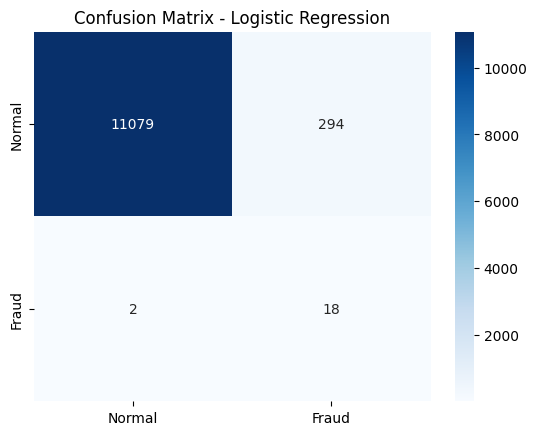

In [ ]:

evaluate_model("Logistic Regression", y_test, y_pred_log)



🔹 Decision Tree Classification Report
              precision    recall  f1-score   support

           0     0.9999    0.9784    0.9890     11373
           1     0.0717    0.9500    0.1333        20

    accuracy                         0.9783     11393
   macro avg     0.5358    0.9642    0.5612     11393
weighted avg     0.9983    0.9783    0.9875     11393

ROC-AUC Score: 0.9641849116328146


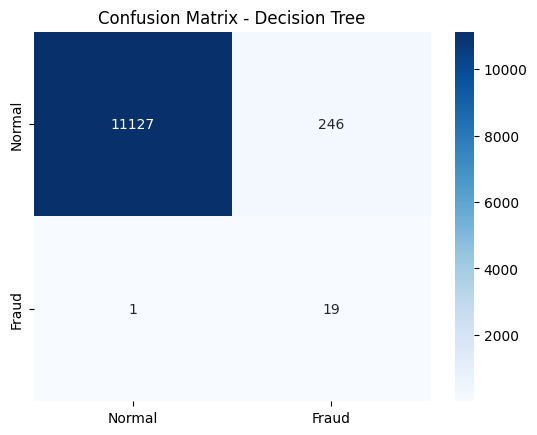

In [ ]:
evaluate_model("Decision Tree", y_test, y_pred_dt)


🔹 Random Forest Classification Report
              precision    recall  f1-score   support

           0     0.9998    0.9983    0.9991     11373
           1     0.4865    0.9000    0.6316        20

    accuracy                         0.9982     11393
   macro avg     0.7432    0.9492    0.8153     11393
weighted avg     0.9989    0.9982    0.9984     11393

ROC-AUC Score: 0.9491646882968434


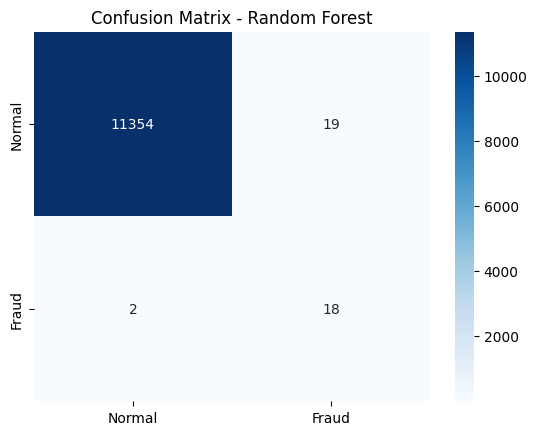

In [ ]:
evaluate_model("Random Forest", y_test, y_pred_rf)

In [ ]:
                                                                                                                                                                       import numpy as np
import pandas as pd


feature_columns = [
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'normAmount'
]



def collect_user_input():
    print("Enter feature values in the following order:")
    print(", ".join(feature_columns))
    values = []
    for col in feature_columns:
        while True:
            v = input(f"Value for {col}: ").strip()
            if v == "":
                print("Input cannot be empty. Please provide a numeric value.")
                continue
            try:
                val = float(v)
                values.append(val)
                break
            except ValueError:
                print("Invalid number. Please enter a numeric value.")
    return np.array(values).reshape(1, -1)

def predict_from_input(model, columns):
    x_input = collect_user_input()

    if x_input.shape[1] != len(columns):
        raise ValueError("Input features do not match training feature count.")

    pred = model.predict(x_input)
    proba = model.predict_proba(x_input)[:, 1] if hasattr(model, "predict_proba") else None
    return pred[0], proba[0] if proba is not None else None

if __name__ == "__main__":
    try:
        pred_label, pred_proba = predict_from_input(dt, feature_columns)
        label_str = "Fraud" if pred_label == 1 else "Normal"
        print(f"\nPrediction: {label_str}")
        if pred_proba is not None:
            print(f"Confidence (Fraud probability): {pred_proba:.4f}")
    except NameError:
        print("Error: Trained Decision Tree model 'dt' is not defined in this session.")
    except Exception as e:
        print(f"An error occurred: {e}")

Enter feature values in the following order:
V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, normAmount
Value for V1: 1
Value for V2: 1
Value for V3: 1
Value for V4: 1
Value for V5: 1
Value for V6: 1
Value for V7: 1
Value for V8: 1
Value for V9: 1
Value for V10: 1
Value for V11: 1
Value for V12: 1
Value for V13: 1
Value for V14: 1
Value for V15: 1
Value for V16: 1
Value for V17: 1
Value for V18: 1
Value for V19: 1
Value for V20: 1
Value for V21: 1
Value for V22: 1
Value for V23: 1
Value for V24: 1
Value for V25: 1
Value for V26: 1
Value for V27: 1
Value for V28: 1
Value for normAmount: 111

Prediction: Normal
Confidence (Fraud probability): 0.0255


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
